In [1]:
import numpy as np 
import pandas as pd
import operator
import os
import chart_studio.tools as tls

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from matplotlib.backend_bases import RendererBase
from scipy import signal
from scipy.io import wavfile

import os
import numpy as np

from PIL import Image

from scipy.fftpack import fft
import librosa
import librosa.display

import plotly as py
tls.set_credentials_file(username='iam4tart',api_key='Docq9bPOpIqBxnDmPIxJ')

import chart_studio.plotly as py
import plotly.graph_objs as go

import cufflinks as cf
import IPython.display as ipd

%matplotlib inline

/var/folders/bq/chj86vfj3c7f11203j8dzrtm0000gn/T/ipykernel_5132/2318503808.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
/Users/pabitraghosh/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import librosa
import numpy as np

def extract_features(audio_path):
    try:
        # Load audio file
        y, sr = librosa.load(audio_path, sr=None)

        # Extract features
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

        # Calculate mean of MFCCs
        mfccs_mean = np.mean(mfccs, axis=1)

        return mfccs_mean

    except Exception as e:
        print("Error encountered while parsing audio: ", audio_path)
        return None

In [4]:
import os
import pandas as pd

def get_files_with_features(path):
    data_ = []
    count = {}
    files = os.listdir(path)
    for file in files:
        labels = file.split("-")[:3]
        if len(labels) < 3:
            continue  # Skip files that don't have enough labels
        
        data = {
            "keyword": labels[0],
            "stress": labels[2],
            "environment": labels[1],
            "path": os.path.join(path, file)
        }
        for label in labels:
            if label not in count.keys():
                count[label] = 1
            else:
                count[label] += 1
        
        # Extract features from audio
        features = extract_features(data['path'])
        if features is not None:
            # Add features to data dictionary
            for i, mfcc in enumerate(features):
                data[f'mfcc_{i+1}'] = mfcc

        data_.append(data)

    if data_:
        df = pd.DataFrame(data_)
    else:
        df = pd.DataFrame(columns=['keyword', 'stress', 'environment', 'path'])
    return data_, count, df

# Example usage
path = '/Users/pabitraghosh/Downloads/destination_folder'
dataset_with_features, count, df_with_features = get_files_with_features(path)
print(df_with_features.head())


      keyword   stress environment  \
0  background     calm        safe   
1        help     calm        safe   
2          no    angry        safe   
3        help     calm        safe   
4        help  fearful        safe   

                                                path      mfcc_1      mfcc_2  \
0  /Users/pabitraghosh/Downloads/destination_fold... -333.849670   86.958153   
1  /Users/pabitraghosh/Downloads/destination_fold... -319.885498  103.440315   
2  /Users/pabitraghosh/Downloads/destination_fold... -304.269012   85.691460   
3  /Users/pabitraghosh/Downloads/destination_fold... -503.992737  118.243744   
4  /Users/pabitraghosh/Downloads/destination_fold... -134.691132   -2.186456   

      mfcc_3     mfcc_4    mfcc_5     mfcc_6    mfcc_7     mfcc_8    mfcc_9  \
0   6.778608  11.708385  6.058447   1.375611 -4.056191  -4.215843 -6.561859   
1 -22.218483  19.574562 -6.087165  10.845435  3.469747   8.410869 -0.556085   
2 -11.335981  10.880747 -7.636560  -7.631079 -9.54837

In [5]:
label_counts = df_with_features['environment'].value_counts()
label_counts1 = df_with_features['stress'].value_counts()
label_counts2 = df_with_features['keyword'].value_counts()
print(label_counts1)
print(label_counts2)
print(label_counts)


stress
calm       7868
fearful    3979
angry      1769
happy      1314
None        625
Name: count, dtype: int64
keyword
background    4428
help          2352
bacho         2332
no            2156
go            1932
unknown       1169
stop           685
yes            501
Name: count, dtype: int64
environment
safe           14089
scream          1246
glass break      180
gunshots          40
Name: count, dtype: int64


In [7]:

print(df_with_features.size)

264435


In [6]:
print(df_with_features.head())

      keyword   stress environment  \
0  background     calm        safe   
1        help     calm        safe   
2          no    angry        safe   
3        help     calm        safe   
4        help  fearful        safe   

                                                path      mfcc_1      mfcc_2  \
0  /Users/pabitraghosh/Downloads/destination_fold... -333.849670   86.958153   
1  /Users/pabitraghosh/Downloads/destination_fold... -319.885498  103.440315   
2  /Users/pabitraghosh/Downloads/destination_fold... -304.269012   85.691460   
3  /Users/pabitraghosh/Downloads/destination_fold... -503.992737  118.243744   
4  /Users/pabitraghosh/Downloads/destination_fold... -134.691132   -2.186456   

      mfcc_3     mfcc_4    mfcc_5     mfcc_6    mfcc_7     mfcc_8    mfcc_9  \
0   6.778608  11.708385  6.058447   1.375611 -4.056191  -4.215843 -6.561859   
1 -22.218483  19.574562 -6.087165  10.845435  3.469747   8.410869 -0.556085   
2 -11.335981  10.880747 -7.636560  -7.631079 -9.54837

In [8]:
selected_columns = df_with_features.columns[4:]
print("Selected columns:", selected_columns)

Selected columns: Index(['mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7',
       'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13'],
      dtype='object')


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
# Prepare data
X = df_with_features.iloc[:, 4:].values  # Features (MFCCs)
y = df_with_features['stress'].values    # Target variable

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded = to_categorical(y_encoded)
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Data Normalization
X_normalized = X_scaled / np.max(np.abs(X_scaled))

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Reshape data for CNN input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [10]:
print(X[0])

[-333.84967     86.95815      6.778608    11.7083845    6.058447
    1.3756106   -4.0561914   -4.215843    -6.561859    -6.6636353
   -7.2503476   -5.0170727   -6.5822   ]


Epoch 1/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5404 - loss: 1.2373 - val_accuracy: 0.6032 - val_loss: 1.0980
Epoch 2/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6057 - loss: 1.0898 - val_accuracy: 0.6024 - val_loss: 1.0422
Epoch 3/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6240 - loss: 1.0224 - val_accuracy: 0.6345 - val_loss: 0.9475
Epoch 4/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6399 - loss: 0.9502 - val_accuracy: 0.6514 - val_loss: 0.9149
Epoch 5/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6657 - loss: 0.8869 - val_accuracy: 0.6739 - val_loss: 0.8725
Epoch 6/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6798 - loss: 0.8432 - val_accuracy: 0.6932 - val_loss: 0.8197
Epoch 7/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6942 - loss: 0.8056 - val_accuracy: 0.7020 - val_loss: 0.7896
Epoch 8/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7074 - loss: 0.7771 - val_accu

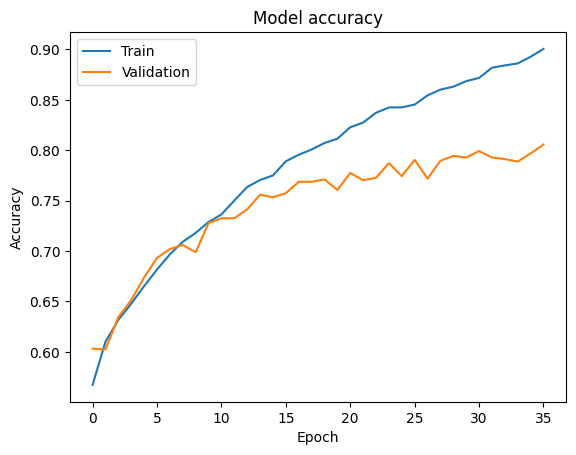

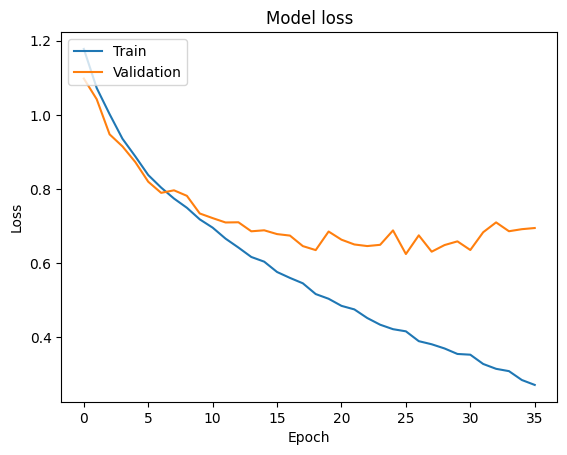

In [11]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
# Define the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(label_encoder.classes_), activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stopping])

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


Epoch 1/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5358 - loss: 1.2488 - val_accuracy: 0.6008 - val_loss: 1.1064 - learning_rate: 0.0010
Epoch 2/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6145 - loss: 1.0549 - val_accuracy: 0.6233 - val_loss: 1.0282 - learning_rate: 0.0010
Epoch 3/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6316 - loss: 1.0015 - val_accuracy: 0.6490 - val_loss: 0.9095 - learning_rate: 0.0010
Epoch 4/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6557 - loss: 0.9221 - val_accuracy: 0.6562 - val_loss: 0.9162 - learning_rate: 0.0010
Epoch 5/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6684 - loss: 0.8861 - val_accuracy: 0.6867 - val_loss: 0.8395 - learning_rate: 0.0010
Epoch 6/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6841 - loss: 0.8414 - val_accuracy: 0.6908 - val_loss: 0.8229 - learning_rate: 0.0010
Epoch 7/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7030 - loss: 0

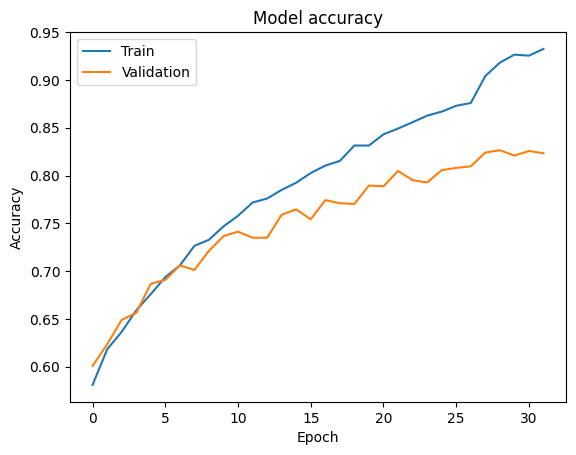

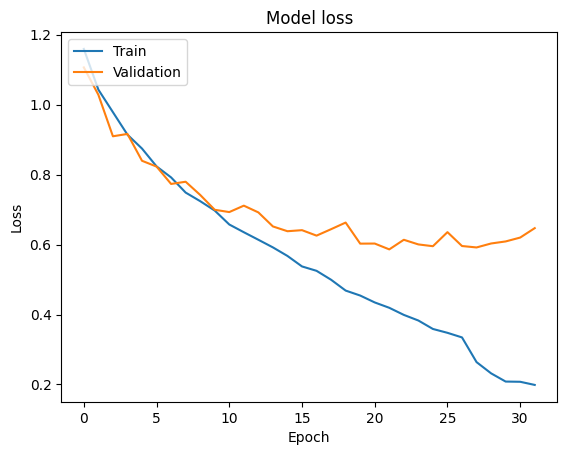

In [12]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the LSTM model
model1 = Sequential()
model1.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model1.add(BatchNormalization())
model1.add(LSTM(64))
model1.add(Dropout(0.5))
model1.add(Dense(64, activation='relu'))
model1.add(Dense(len(label_encoder.classes_), activation='softmax'))

# Compile the model
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

# Train the model with early stopping and learning rate scheduling
history = model1.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stopping, reduce_lr])

# Evaluate the model
loss, accuracy = model1.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


Epoch 1/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5479 - loss: 1.2260 - val_accuracy: 0.5952 - val_loss: 1.0961 - learning_rate: 0.0010
Epoch 2/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6044 - loss: 1.0710 - val_accuracy: 0.6064 - val_loss: 1.0342 - learning_rate: 0.0010
Epoch 3/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6339 - loss: 1.0015 - val_accuracy: 0.6305 - val_loss: 0.9588 - learning_rate: 0.0010
Epoch 4/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6594 - loss: 0.9218 - val_accuracy: 0.6699 - val_loss: 0.8957 - learning_rate: 0.0010
Epoch 5/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6656 - loss: 0.8775 - val_accuracy: 0.6731 - val_loss: 0.8554 - learning_rate: 0.0010
Epoch 6/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6935 - loss: 0.8260 - val_accuracy: 0.6892 - val_loss: 0.8165 - learning_rate: 0.0010
Epoch 7/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6998 - loss: 0.

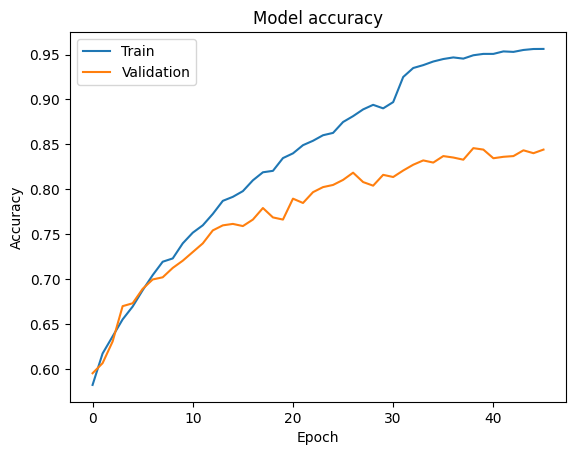

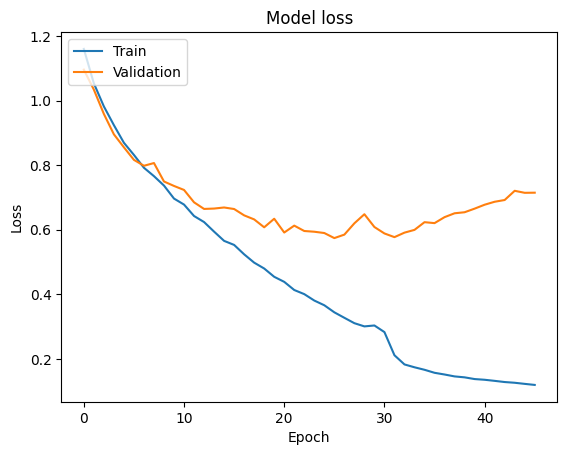

In [13]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the LSTM model
model2 = Sequential()
model2.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model2.add(BatchNormalization())
model2.add(LSTM(64))
model2.add(Dropout(0.5))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(len(label_encoder.classes_), activation='softmax'))

# Compile the model
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.0001)

# Train the model with early stopping and learning rate scheduling
history = model2.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stopping, reduce_lr])

# Evaluate the model
loss, accuracy = model2.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:

# from keras.callbacks import EarlyStopping

# # Define the CNN model
# model = Sequential()
# model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
# model.add(MaxPooling1D(pool_size=2))
# model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
# model.add(MaxPooling1D(pool_size=2))
# model.add(Flatten())
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(len(label_encoder.classes_), activation='softmax'))

# # Compile the model
# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# # Define early stopping
# early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)

# # Train the model with early stopping
# history = model.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stopping])

# # Evaluate the model
# loss, accuracy = model.evaluate(X_test, y_test)
# print("Test Accuracy:", accuracy)
# print("Loss:", loss)

# # Plot training & validation accuracy values
# plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])
# plt.title('Model accuracy')
# plt.ylabel('Accuracy')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Validation'], loc='upper left')
# plt.show()

# # Plot training & validation loss values
# plt.plot(history.history['loss'])
# plt.plot(history.history['val_loss'])
# plt.title('Model loss')
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Validation'], loc='upper left')
# plt.show()



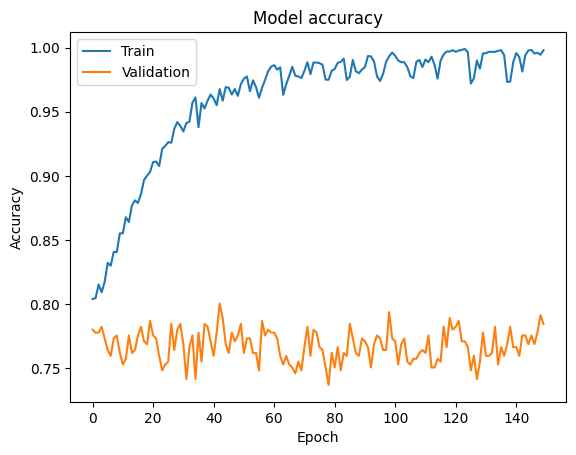

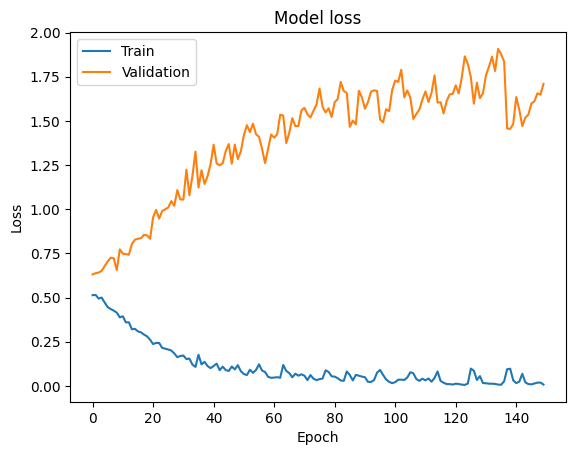

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7328 - loss: 2.1511
Test Accuracy: 0.7402361631393433
Loss: 2.1871554851531982


In [ ]:
import matplotlib.pyplot as plt

# Train the model
history = model.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.1, verbose=0)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)
print("Loss:", loss)


In [ ]:
# def extract_features(file_path, duration=3, sr=16000, n_mfcc=13, max_frames=150):
#     y, sr = librosa.load(file_path, sr=sr, duration=duration)
#     mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
#     # Pad or truncate to a fixed number of frames
#     if mfccs.shape[1] < max_frames:
#         mfccs = np.pad(mfccs, ((0, 0), (0, max_frames - mfccs.shape[1])), mode='constant')
#     else:
#         mfccs = mfccs[:, :max_frames]
#     return mfccs.T  # Transpose to have time along the columns

